In [2]:
import pandas as pd
import numpy as np
from datatools import get_index_K, get_price, get_cyq, get_rzrq, get_moneyflow, get_technical,strategy_metrics
import lightgbm as lgb
import matplotlib.pyplot as plt
from cal_cne6_factor import calc_cne6_factors

### 取特征及样本

In [2]:
allstock = pd.read_csv('data/allstock.csv')
allstock_list = allstock[(allstock['list_date'] < 20260101) & ~allstock['ts_code'].str.contains('BJ') &((allstock['delist_date'] >= 20190101)|(allstock['delist_date'].isna()))].ts_code.tolist()
delist = allstock[(allstock['list_date'] < 20260101) & ~allstock['ts_code'].str.contains('BJ') &(allstock['delist_date'] >= 20190101)].ts_code.tolist()
start_date = '2019-01-01'
end_date = '2026-03-31'

In [3]:
all_sample = get_price(allstock_list, '2019-01-01', '2026-05-31',fields=['open', 'adj_factor'])
all_sample['20d_returns'] = all_sample.groupby('ts_code')['open'].shift(-20) / all_sample['open'] - 1
all_sample.rename(columns={'open':'next_open'}, inplace=True)
all_sample = all_sample.fillna(-0.9999999)
all_sample['trade_date'] = all_sample.groupby('ts_code')['trade_date'].shift(1)
all_sample = all_sample[all_sample.trade_date.between(start_date, end_date)]

In [6]:
bench = get_index_K(['000852.SH'], start_date='2019-01-01', end_date='2026-05-31', fields=['open'])
bench['bench_20d_return'] = bench['open'].shift(-20) / bench['open'] -1
bench['trade_date'] = bench['trade_date'].shift(1)

all_sample = all_sample.merge(bench[['trade_date', 'bench_20d_return']], on='trade_date', how='left')
all_sample['20d_excess_returns'] = all_sample['20d_returns'] - all_sample['bench_20d_return']
all_sample['Y_20d'] = all_sample.groupby('trade_date')['20d_excess_returns'].rank(pct=True)

In [9]:
all_sample.to_parquet('data/factor/all_sample.parquet', index=False)

In [20]:
factor1_de = calc_cne6_factors(delist, '2019-01-01', '2026-03-31')

cyq = get_cyq(delist, '2019-01-01', '2026-03-31')
rzrq = get_rzrq(delist, '2019-01-01', '2026-03-31')
monthflow = get_moneyflow(delist, '2019-01-01', '2026-03-31')

tech = get_technical(delist, '2019-01-01', '2026-03-31')

加载价格数据...
加载指数数据...
矩阵: 2019 交易日 × 221 只股票
计算 Daily std...
计算 Cumulative range...


c:\Users\User\Desktop\Quant\cal_cne6_factor.py:99: RuntimeWarning: All-NaN slice encountered
  factor_values = np.nanmax(window_rets, axis=0) - np.nanmin(window_rets, axis=0)


计算 Short Term reversal...
计算 Seasonality...
计算 Industry Momentum...
计算 BETA / Hist sigma / Historical alpha...
计算 Relative strength...
加载长期价格数据...
加载长期指数数据...
计算 Long term relative strength...
计算 Long term historical alpha...
加载基础数据...
加载财务数据...
加载TTM数据...
计算换手率因子...
计算市值因子...
计算估值/杠杆因子...
计算盈利能力...
计算财务质量因子...
计算应计项目...
计算投资质量...
加载分析师预测数据...
计算分析师预测因子...
组装结果...
done


In [ ]:
factor1_de = factor1_de[~factor1_de['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor1 = pd.concat([factor1, factor1_de]).sort_values(['trade_date','ts_code'])
factor1.to_parquet('data/factor/cne6_factor.parquet', index=False)

In [ ]:
factor2_de = pd.merge(cyq, rzrq, on=['trade_date', 'ts_code'], how='outer').merge(monthflow, on=['trade_date', 'ts_code'], how='outer')
factor2_de = factor2_de[~factor2_de['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor2 = pd.concat([factor2, factor2_de]).sort_values(['trade_date','ts_code'])
factor2.to_parquet('data/factor/other_factor.parquet', index=False)

In [ ]:
tech = tech[~tech['ts_code'].isin(['300344.SZ', '300391.SZ', '600355.SH'])]
factor3 = pd.concat([factor3, tech]).sort_values(['trade_date','ts_code'])
factor3.to_parquet('data/factor/tech_factor.parquet', index=False)

In [ ]:
sample = all_sample.query( 'trade_date >= "2023-01-01"') ## oot
#sample = all_sample.query( 'trade_date < "2023-01-01"') # train
factor = sample.merge(factor1, on=['ts_code', 'trade_date'], how='left').merge(
    factor2, on=['ts_code', 'trade_date'], how='left').merge(factor3, on=['ts_code', 'trade_date'], how='left')

In [ ]:
ind = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/industry.csv')
factor = factor.merge(ind[['ts_code', 'l1_name']], on='ts_code', how='left')
factor = pd.get_dummies(factor, columns=['l1_name'], drop_first=True, dtype=int)
#daily_corr = factor.groupby('trade_date').apply(lambda x: x[factor.columns[8:]].corrwith(x['Y_20d'])).reset_index()

In [ ]:
def neutralize_date(group):
    X_raw = group[factor.columns[-30:].tolist() + ['lncap']].values
    X = np.column_stack((np.ones(X_raw.shape[0]), X_raw))
    # 预分配残差矩阵，默认全为 NaN
    resid_matrix = np.full((group.shape[0], 155), np.nan)
    # 2. 必须按列独立回归，处理各自的缺失值
    for j, col in enumerate(factor.columns[8:-30]):
        try:
            median = group[col].median()
            mad = (group[col] - median).abs().median()
            group[col] = group[col].clip(median - 5 * mad, median + 5 * mad)
            mean = group[col].mean()
            std = group[col].std()
            if std == 0:
                group[col] = np.nan  # 波动为0的因子无信息，置0
            else:
                group[col] = (group[col] - mean) / std
            
            Y_raw = group[col].values
            # 核心：只判断当前因子列的缺失值
            valid_idx = ~np.isnan(Y_raw) & np.all(~np.isnan(X), axis=1)
            X_valid = X[valid_idx]
            Y_valid = Y_raw[valid_idx]
            # 3. 底层 NumPy 最小二乘法求解
            beta, _, _, _ = np.linalg.lstsq(X_valid, Y_valid[:, np.newaxis])
            # 计算残差并展平为一维
            resid_valid = Y_valid - (X_valid @ beta).flatten()
            # 4. 只将有效行的残差填入对应位置，无效行保持 NaN
            resid_matrix[valid_idx, j] = resid_valid
        except:
            print(group.name, col)
    # 5. 映射回 DataFrame
    group[factor.columns[8:-30]] = resid_matrix
    return group
factor =  factor.groupby('trade_date').apply(neutralize_date).reset_index(level=0)
factor = factor.drop(columns=factor.columns[-30:].tolist() + ['lncap'])

In [ ]:
factor.to_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_oot.parquet', index=False)

#### training

In [3]:
sample_train = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_train.parquet')
sample_oot = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_oot.parquet')
sample_oot['daily_return'] = sample_oot.groupby('ts_code')['next_open'].pct_change().fillna(0)

In [ ]:
# 从 train_val_df 中切出 20% 作为验证集 (按时间切，比如22年全年)
val_df = sample_train[sample_train['trade_date'] >= '2022-05-01']
train_df = sample_train[sample_train['trade_date'] < '2022-05-01']
feature_cols = sample_train.columns[8:]
lgb_train = lgb.Dataset(train_df[feature_cols], train_df['Y_20d'])
lgb_val = lgb.Dataset(val_df[feature_cols], val_df['20d_excess_returns'])
lgb_val.set_group(val_df.groupby('trade_date').size().values)

In [17]:
lgb_params = {
    'objective': 'regression', 
    'learning_rate': 0.03,     
    'max_depth': 4,            
    'num_leaves': 10,          
    'subsample': 0.7,          
    'colsample_bytree': 0.6,   
    'reg_alpha': 0.5,          
    'reg_lambda': 1.0,         
    'min_child_samples': 200,  
    'n_estimators': 1000,      
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

def sharpe_eval(y_pred, dataset):
    y_true = dataset.get_label()
    group_sizes = dataset.get_group()
    daily_returns = []
    start_idx = 0
    # 遍历每一天
    for size in group_sizes:
        # 切出当天的预测值和真实值
        pred_day = y_pred[start_idx : start_idx + size]
        true_day = y_true[start_idx : start_idx + size]
        # 假设等权做多预测值前10%
        daily_returns.append(np.mean(true_day[pred_day > np.percentile(pred_day, 90)]))
        # 移动索引到下一天
        start_idx += size
    # 计算整个验证集上的夏普比率
    daily_returns = np.array(daily_returns)
    sharpe = np.mean(daily_returns) / np.std(daily_returns)
    # 返回格式: (名称, 值, 是否越大越好)
    return 'sharpe', sharpe, True
# 3. 训练模型
model = lgb.train(
    lgb_params,
    lgb_train,
    valid_sets=[lgb_val],
    feval=sharpe_eval, 
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(1)]
    )
# 在 OOT 集(23年+)上进行日频预测 对预测结果做截面标准化
sample_oot['predict_score'] = model.predict(sample_oot[feature_cols])
daily_ic = sample_oot.groupby('trade_date').apply(lambda x: x['predict_score'].corr(x['Y_20d'], method='spearman'))

c:\Users\User\miniconda3\envs\mindigital\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\miniconda3\envs\mindigital\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


[1]	valid_0's l2: 0.0832486	valid_0's sharpe: nan
Training until validation scores don't improve for 10 rounds
[2]	valid_0's l2: 0.0831626	valid_0's sharpe: nan
[3]	valid_0's l2: 0.0830862	valid_0's sharpe: nan
[4]	valid_0's l2: 0.0830057	valid_0's sharpe: nan
[5]	valid_0's l2: 0.0829296	valid_0's sharpe: nan
[6]	valid_0's l2: 0.0828624	valid_0's sharpe: nan
[7]	valid_0's l2: 0.0827967	valid_0's sharpe: nan
[8]	valid_0's l2: 0.0827288	valid_0's sharpe: nan
[9]	valid_0's l2: 0.0826634	valid_0's sharpe: nan
[10]	valid_0's l2: 0.0826031	valid_0's sharpe: 14.6427
[11]	valid_0's l2: 0.0825455	valid_0's sharpe: 14.6416
Early stopping, best iteration is:
[1]	valid_0's l2: 0.0832486	valid_0's sharpe: nan


In [4]:
feat_imp_df = pd.DataFrame({'feature': model.feature_name(), 'gain': model.feature_importance(importance_type='gain')})
feat_imp_df['gain'] /= feat_imp_df['gain'].sum()
feat_imp_df = feat_imp_df.sort_values(by='gain', ascending=False)
print("Top 10 Features by Gain:")
print(feat_imp_df.head(10))

Top 10 Features by Gain:
           feature      gain
12            stom  0.139175
6       hist_sigma  0.111884
61  sell_md_amount  0.088846
55   buy_sm_amount  0.043826
86       bias3_hfq  0.040609
0        daily_std  0.040167
47       cost_5pct  0.035926
41            adtp  0.032413
44       delta_cnt  0.031374
43       delta_eps  0.022514


### step 4

In [ ]:
# sample_oot : DataFrame, 包含 'trade_date', 'ts_code','daily_return' 列
# trade_records : DataFrame, 交易记录, 包含 'ts_code', 'buy_date', 'buy_price', 'sell_date', 'sell_price' 列

In [4]:
sample_oot['sell_price'] = sample_oot.groupby('ts_code')['next_open'].shift(-20)
sample_oot['sell_date'] = sample_oot.groupby('ts_code')['trade_date'].shift(-20)

unique_dates = sample_oot['trade_date'].drop_duplicates().sort_values().reset_index(drop=True)
signal_dates = set(unique_dates[(unique_dates.index) % 20 == 0])
signal_df = sample_oot[sample_oot['trade_date'].isin(signal_dates)]
trade_records = signal_df[signal_df.groupby('trade_date')['predict_score'].rank(method='first', pct=True) >= 0.9]
trade_records = trade_records[['ts_code', 'trade_date', 'next_open', 'sell_date', 'sell_price']].rename(columns={'trade_date': 'buy_date', 'next_open': 'buy_price'})
trade_records = trade_records[trade_records.sell_date.notna()]

In [6]:
metrics, df_res = strategy_metrics(sample_oot[['trade_date', 'ts_code', 'daily_return']], trade_records, '000852.SH')

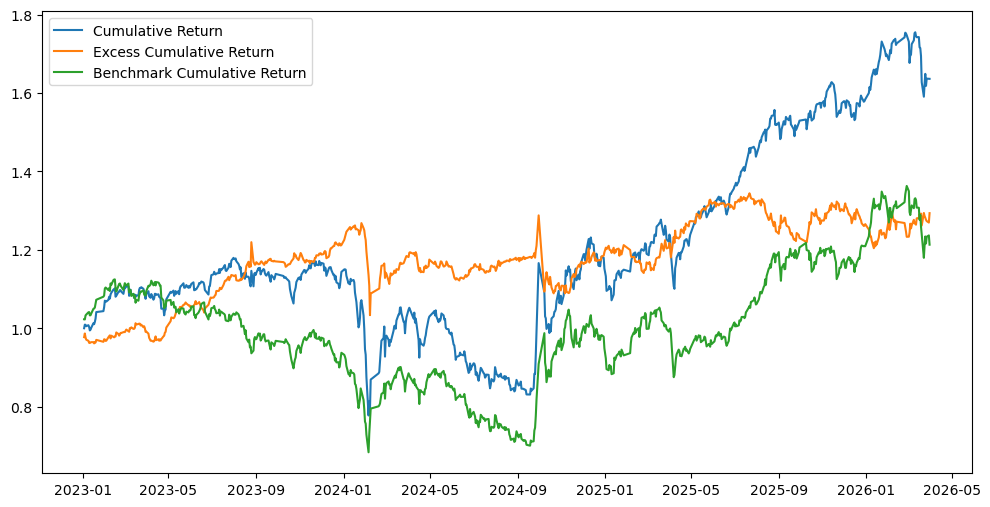

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df_res['trade_date'], df_res['cum_nav'], label='Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_excess_nav'], label='Excess Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_bench_nav'], label='Benchmark Cumulative Return')
plt.legend()
plt.show()